In [1]:
import numpy as np
import matplotlib.pyplot as plt
from cr3bp import create_earth_moon_system, plot_trajectory, decision_to_state0, constraint, objective_func

In [2]:
em = create_earth_moon_system()
print(em.info)

<bound method CR3BPSystem.info of CR3BPSystem(m1=5.972e+24 kg, m2=7.342e+22 kg, d=3.844e+08 m, mu=0.012145)>


In [3]:
leo_alt_m=463e3
lmo_alt_m=100e3

In [4]:
x0 = np.array([4.065625, 3.009677, -0.645494, 0.80645161])
state0 = decision_to_state0(em, x0, leo_alt_m)

In [5]:
tof = x0[3]
t_span = (0,tof)
t_eval = np.linspace(0, tof, 1000)
states, ts, sol = em.solve(state0, t_span, t_eval)

In [6]:
constraint_value = constraint(em, x0, leo_alt_m=leo_alt_m, lmo_alt_m=lmo_alt_m)

Final Rocket Pos [3.79644671e+08 2.42245123e+06 0.00000000e+00]
Final Moon Pos [3.79731565e+08 0.00000000e+00 0.00000000e+00]


In [9]:
objective_value = objective_func(em, x0, leo_alt_m)
print(objective_value)

4.269066155928515


Distance from moon : 2424 km
Total Delta_v required : 4.37 km/s


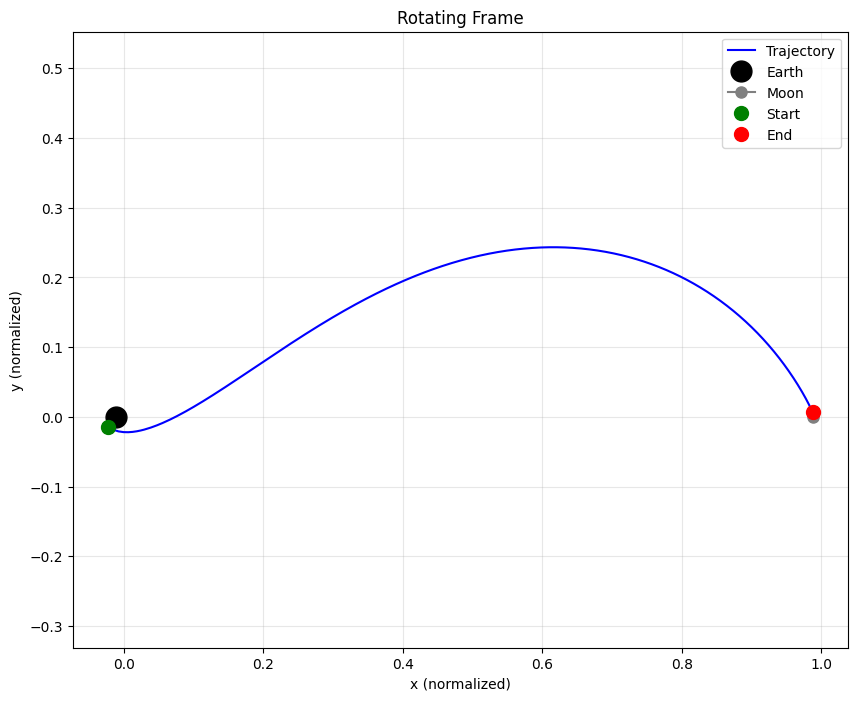

In [13]:
pos_f = states[:,-1][0:3]
#print(f"Rocket Final Pos in Rotating Frame (normalized units): {pos_f}")
print(f"Distance from moon : {1e-3*(constraint_value*em.l_star + lmo_alt_m):.0f} km")
print(f"Total Delta_v required : {objective_value*em.v_star * 1e-3:.2f} km/s")
plot_trajectory(states, em.mu, t_eval, frame="Rotating")